# Iris Flower Classification using Decision Tree

This project builds a machine learning model to classify iris flowers into Setosa, Versicolor, or Virginica using a Decision Tree classifier.

In [1]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 120
Test samples: 30


In [3]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [4]:
y_pred = model.predict(X_test)
print("Predictions:", y_pred)
print("True labels:", y_test)

Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
True labels: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [5]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [6]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=iris.target_names, columns=iris.target_names)
print("Confusion Matrix:\n", cm_df)

Confusion Matrix:
             setosa  versicolor  virginica
setosa          10           0          0
versicolor       0           9          0
virginica        0           0         11


In [7]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, target_names=iris.target_names)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [8]:
for name, importance in zip(iris.feature_names, model.feature_importances_):
    print(f"{name}: {importance:.2f}")

sepal length (cm): 0.00
sepal width (cm): 0.02
petal length (cm): 0.91
petal width (cm): 0.08


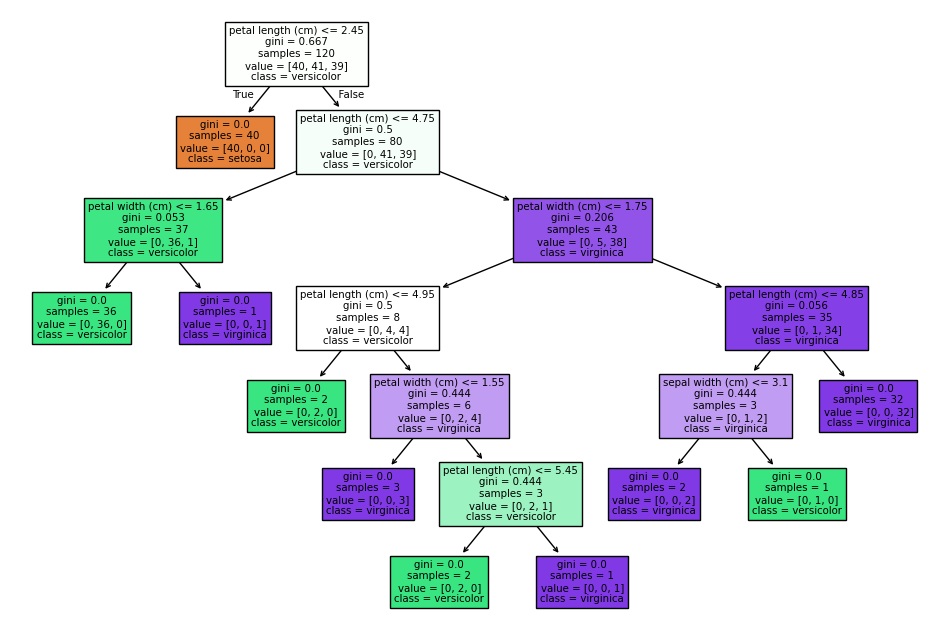

In [9]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

In [10]:
# Step 1: Original Decision Tree
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)
print("Decision Tree accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree accuracy: 1.0


In [11]:
# Step 2: k-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)
print("k-NN accuracy:", accuracy_score(y_test, y_pred_knn))

k-NN accuracy: 1.0


In [12]:
# Step 3: Support Vector Machine
from sklearn.svm import SVC

model_svm = SVC(kernel='linear', random_state=42)
model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)
print("SVM accuracy:", accuracy_score(y_test, y_pred_svm))

SVM accuracy: 1.0


In [13]:
# Step 4: Tuned Decision Tree
model_dt_tuned = DecisionTreeClassifier(max_depth=3, random_state=42)
model_dt_tuned.fit(X_train, y_train)

y_pred_dt_tuned = model_dt_tuned.predict(X_test)
print("Tuned Decision Tree accuracy:", accuracy_score(y_test, y_pred_dt_tuned))

Tuned Decision Tree accuracy: 1.0


In [14]:
# Step 5: Feature Importance
import pandas as pd

features = iris.feature_names
importances = model_dt_tuned.feature_importances_

feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
print(feature_importance_df)

             Feature  Importance
0  sepal length (cm)    0.000000
1   sepal width (cm)    0.000000
2  petal length (cm)    0.934626
3   petal width (cm)    0.065374


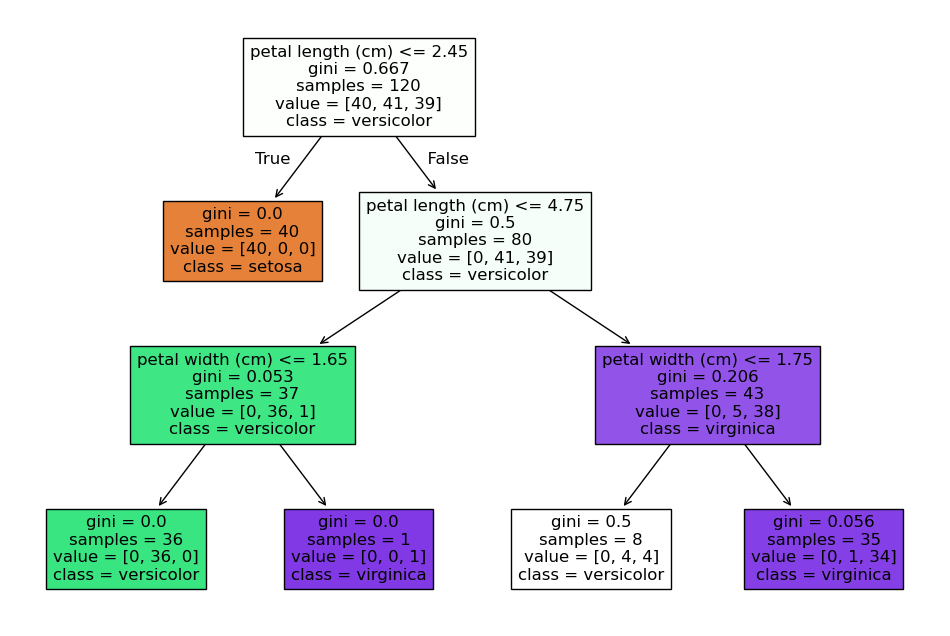

In [15]:
# Step 6: Visualize Decision Tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(model_dt_tuned, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

In [16]:
# Step 7: Feature Engineering - Petal ratio
import numpy as np

X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

# Add petal length / petal width ratio
petal_ratio_train = X_train[:,2] / X_train[:,3]
petal_ratio_test = X_test[:,2] / X_test[:,3]

X_train_fe = np.column_stack((X_train, petal_ratio_train))
X_test_fe = np.column_stack((X_test, petal_ratio_test))

# Train new Decision Tree with engineered feature
model_dt_fe = DecisionTreeClassifier(random_state=42)
model_dt_fe.fit(X_train_fe, y_train)

y_pred_dt_fe = model_dt_fe.predict(X_test_fe)
print("Decision Tree with feature engineering accuracy:", accuracy_score(y_test, y_pred_dt_fe))

Decision Tree with feature engineering accuracy: 0.9666666666666667


In [17]:
# Step 8: Summary of all models
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("k-NN:", accuracy_score(y_test, y_pred_knn))
print("SVM:", accuracy_score(y_test, y_pred_svm))
print("Tuned Decision Tree:", accuracy_score(y_test, y_pred_dt_tuned))
print("Decision Tree + Feature Engineering:", accuracy_score(y_test, y_pred_dt_fe))

Decision Tree: 1.0
k-NN: 1.0
SVM: 1.0
Tuned Decision Tree: 1.0
Decision Tree + Feature Engineering: 0.9666666666666667
